In [ ]:
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
import imageio.v3 as iio3
import cv2 

In [3]:
filename = 'led.png'

raw_img = ski.io.imread(filename)
print(raw_img.shape) 

(851, 1070, 4)


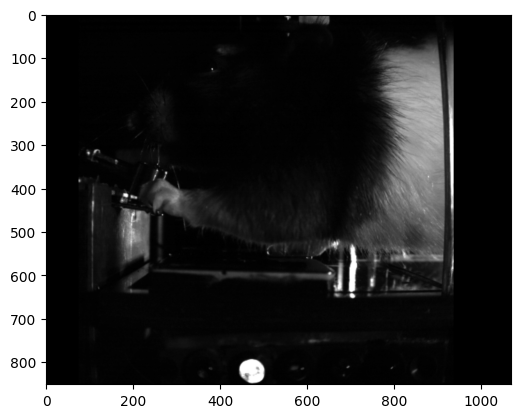

In [4]:
plt.imshow(raw_img, cmap='gray')

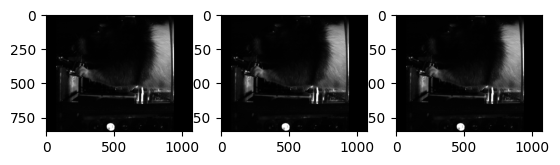

In [5]:
red = raw_img[:, :, 0]  # ":" -> on récupe tous les élement, '0' -> on récupe la couleurs d'indice 0
green = raw_img[:, :, 1]
blue = raw_img[:, :, 2]

fig,ax = plt.subplots(1,3)  # (nb ligne, bn colonne)
ax[0].imshow(red, cmap='gray')
ax[1].imshow(green, cmap='gray')
ax[2].imshow(blue, cmap='gray')
plt.show()

In [6]:
# put image to gray level
raw_img = raw_img[:, :, 0]

In [7]:
import matplotlib.patches as patches

In [8]:
led_region = {'y_top' : 0,
              'y_bottom' : 0}

In [9]:
raw_img.shape

(851, 1070)

In [ ]:
def scan_frame(y_top, y_bottom):
    
    # x points never changes
    x_top = 0
    x_bottom = raw_img.shape[1]

    # save point location
    led_region['y_top'] = y_top
    led_region['y_bottom'] = y_bottom

    # make img continuous
    img = np.ascontiguousarray(raw_img, dtype=np.uint8)
    
    # draw rectangle to show where to crop
    cv2.rectangle(img, (x_top, y_top), (x_bottom, y_bottom), (255,0,0), 2)

    plt.imshow(img, cmap='gray')
    plt.title(f'Framing leds')
    plt.axis('off')
    plt.show()

widgets.interact(scan_frame, 
                y_top=(0, raw_img.shape[0]),
                y_bottom=(0, raw_img.shape[0]))

interactive(children=(IntSlider(value=425, description='y_top', max=851), IntSlider(value=425, description='y_…

<function __main__.scan_frame(y_top, y_bottom)>

In [11]:
print(led_region)
# print(led_region)

{'y_top': 784, 'y_bottom': 851}


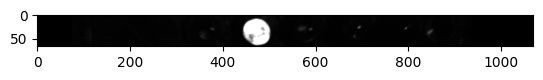

In [12]:
cropped_img = raw_img[led_region['y_top'] : led_region['y_bottom'], : ] 

plt.imshow(cropped_img, cmap='gray')

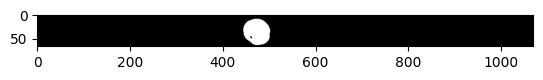

In [13]:
# mettre l'image en binaire avec otsu pour extraire le plus d'info lumineuse
otsu_filter = ski.filters.threshold_otsu(cropped_img)
binary = cropped_img > otsu_filter

plt.imshow(binary, cmap='gray')

In [14]:
# analyse particle
# on va utiliser un kernel qui va générer une liste pour chaque objet
label = ski.measure.label(binary)
print(np.min(label), np.max(label))  # 0 (le background) 206 [le nb d'objet]

# mesure de différente métrique (aire, perimetre etc..)
prop = ski.measure.regionprops(label, cropped_img)
for i, region in enumerate(prop) : # i = position, region = la valeurs a cette position
	print("___OBJECT N°",i, "___")
	print("area =", region.area)
	print("centroid coordinates =", region.centroid)


0 1
___OBJECT N° 0 ___
area = 2508.0
centroid coordinates = (36.66228070175438, 474.0709728867624)


## For next time : 

- regler le cropping (is it necessary realy ? --> maybe check time exectution)
- binary image
- get label : ski.measure.label(binary)
- region center_point in prop = ski.measure.regionprops(label, gray) : 

### important = figure out how to know wich led is activated ???

### draw circle of the led to evaluate their distances

In [17]:
center_coord = prop[0].centroid
center_coord

(36.66228070175438, 474.0709728867624)

In [18]:
cropped_img.shape

(67, 1070)

In [ ]:
def draw_leds(x_led1, x_led2, x_led3, x_led4, x_led5, radius):
    
    # y center poitn never changes
    y = int(center_coord[0])
    print(y)

    # make img continuous
    img = np.ascontiguousarray(cropped_img, dtype=np.uint8)
    
    # draw rectangle to show where to crop
    for x in [x_led1, x_led2, x_led3, x_led4, x_led5]:
        cv2.circle(img, (x, y), radius, (255, 0, 0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Drawing leds positions')
    plt.axis('off')
    plt.show()

widgets.interact(draw_leds, 
                x_led1=(0, cropped_img.shape[1]-1),
                x_led2=(0, cropped_img.shape[1]-1),
                x_led3=(0, cropped_img.shape[1]-1),
                x_led4=(0, cropped_img.shape[1]-1),
                x_led5=(0, cropped_img.shape[1]-1),
                radius=(1, cropped_img.shape[0] // 2))

interactive(children=(IntSlider(value=534, description='x_led1', max=1069), IntSlider(value=534, description='…

<function __main__.draw_leds(x_led1, x_led2, x_led3, x_led4, x_led5, radius)>